# Permit Delays v2: Feature Mining, Calibration, and Custom Deadlines

The [first version of this project](eda.ipynb) predicted whether a San Diego building permit would be delayed (>66 days, the 75th percentile of 2024 approvals) using three signals: permit type, submission month, and location. It scored 85.1% accuracy / 0.916 ROC-AUC on a held-out 2025 test year.

This notebook is the story of the second pass:

1. **Feature mining** — what signal was hiding in the 50 columns v1 ignored
2. **v1 vs v2** — a controlled comparison on the same test year
3. **SHAP** — what drives the upgraded model
4. **Error analysis** — where the model is still wrong

Everything here loads artifacts produced by [`train.py`](train.py), the reproducible pipeline (`python train.py` regenerates all of it from the raw CSVs). Decisions and their reasoning are logged in [DECISIONS.md](DECISIONS.md).

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from features import engineer_features, friendly_name
from train import load_and_clean

%matplotlib inline

# Raw data, cleaned the same way as training (drop negative durations,
# then drop rows missing coordinates for modeling)
train_full, train_df = load_and_clean("data/approvals_issued_2024_datasd.csv")
_, test_df = load_and_clean("data/approvals_issued_2025_datasd.csv")

cutoff = float(joblib.load("cutoff.pkl"))
y_train = (train_df["days_to_approval"] > cutoff).astype(int)
y_test = (test_df["days_to_approval"] > cutoff).astype(int)

print(f"train (2024): {len(train_df):,} rows, delay rate {y_train.mean():.1%}")
print(f"test  (2025): {len(test_df):,} rows, delay rate {y_test.mean():.1%}")
print(f"'delayed' means > {cutoff:.0f} days")

train (2024): 52,974 rows, delay rate 25.9%
test  (2025): 52,590 rows, delay rate 23.1%
'delayed' means > 66 days


## 1. What else is in this dataset?

v1 used 4 raw columns. The dataset has 54. Most of the rest are sparsely populated — but sparsity isn't uselessness, and for several columns *whether a value is present at all* turns out to carry signal.

The screening rule for every candidate: **is this knowable at submission time?** Anything determined during or after review (close dates, expire dates, status) is leakage and untouchable. For a few kept columns we make documented assumptions — the processing track and scope description are treated as set at intake (the data snapshot can't prove they're never edited mid-review; see DECISIONS.md).

In [2]:
candidates = [
    "PROJECT_ID", "APPROVAL_PROCESSING_CODE", "APPROVAL_VALUATION",
    "APPROVAL_SCOPE", "APPROVAL_PERMIT_HOLDER", "JOB_BC_CODE_DESCRIPTION",
]
pd.DataFrame({
    "coverage": [f"{train_df[c].notna().mean():.1%}" for c in candidates],
    "example": [str(train_df[c].dropna().iloc[0])[:60] for c in candidates],
}, index=candidates)

,coverage,example
PROJECT_ID,40.5%,663313
APPROVAL_PROCESSING_CODE,38.1%,Standard
APPROVAL_VALUATION,12.4%,0.0
APPROVAL_SCOPE,40.3%,Request for alternate to project 650673 to all...
APPROVAL_PERMIT_HOLDER,92.8%,"SGPA , Stephanie Antl"
JOB_BC_CODE_DESCRIPTION,26.4%,Add/Alt Tenant Improvements


Coverage looks discouraging until you look at delay rates conditioned on these columns. Every one of them splits the data dramatically:

In [3]:
d = train_df.assign(delayed=y_train)

print("Linked to a larger project? (PROJECT_ID present)")
print(d.groupby(d["PROJECT_ID"].notna()).delayed.agg(["size", "mean"]).round(3), "\n")

print("Processing track:")
print(d.groupby(d["APPROVAL_PROCESSING_CODE"].fillna("(missing)")).delayed
       .agg(["size", "mean"]).round(3).sort_values("size", ascending=False), "\n")

val = pd.to_numeric(d["APPROVAL_VALUATION"], errors="coerce")
has_val = val.notna() & (val > 0)
print("Declared a positive valuation?")
print(d.groupby(has_val).delayed.agg(["size", "mean"]).round(3), "\n")

freq = d["APPROVAL_PERMIT_HOLDER"].value_counts()
vol = d["APPROVAL_PERMIT_HOLDER"].map(freq).fillna(0)
print("Permit holder's 2024 volume:")
print(d.groupby(pd.cut(vol, [-1, 1, 10, 100, 1e6],
                labels=["1", "2-10", "11-100", ">100"]), observed=True)
       .delayed.agg(["size", "mean"]).round(3))

Linked to a larger project? (PROJECT_ID present)
             size   mean
PROJECT_ID              
False       31514  0.011
True        21460  0.624 

Processing track:
                           size   mean
APPROVAL_PROCESSING_CODE              
(missing)                 32810  0.041
Standard                  12573  0.545
Express                    6689  0.751
Expedite                    415  0.954
undefined                   399  0.291
Not Required                 88  0.011 

Declared a positive valuation?
                     size   mean
APPROVAL_VALUATION              
False               46485  0.193
True                 6489  0.735 

Permit holder's 2024 volume:
                         size   mean
APPROVAL_PERMIT_HOLDER              
1                       10014  0.448
2-10                    12523  0.448
11-100                  12602  0.210
>100                    17835  0.056


A permit tied to a larger development project is **62x** more likely to be delayed than a standalone one (1% vs 62%). The processing track spans 0.1% ("Not Required") to 95% ("Expedite" — expedited review is *bought for* exactly the complex projects that run long). Declaring a valuation — which only plan-review permits do — carries a 73% delay rate, rising with the amount. And who pulls the permit matters: high-volume contractors run 5.6% delayed vs 38% for one-time applicants.

**Kept** (all one-hot or log-scaled, built in [`features.py`](features.py)): project linkage, processing track, valuation + has-valuation flag, scope description length, permit-holder annual volume.

**Skipped**: `JOB_BC_CODE` (25% coverage, largely re-encodes permit type), project age (non-monotonic), and every post-decision column (leakage).

One subtlety: these fields' *missingness* correlates with permit type (No-Plan permits have no project, no valuation, no scope). The model already knows the type, so the question is whether the new features add signal *within* type — which the comparison below answers.

## 2. v1 vs v2, same test year

[`train.py`](train.py) first re-trains the v1 feature set (type + month + lat/long) and verifies it reproduces the originally documented metrics **exactly** — same cutoff, same cleaning order, same top-15 type computation. That matters: two pipeline-reproduction bugs (computing the cutoff and the top-15 list *after* the coordinate drop instead of before) were caught precisely because the numbers didn't match. With the reproduction verified, the v2 comparison is apples-to-apples.

In [4]:
with open("figures/metrics.json") as f:
    metrics = json.load(f)

comparison = pd.DataFrame({
    "v1 (type+month+location)": metrics["v1"],
    "v2 (+ project context)": metrics["v2"],
}).drop(index=["model"]).astype(float).round(3)
comparison

,v1 (type+month+location),v2 (+ project context)
accuracy,0.851,0.873
precision,0.657,0.693
recall,0.749,0.806
roc_auc,0.916,0.942


Recall is the headline: **74.9% → 80.6%** of delayed permits caught, with precision *also* up. AUC 0.916 → 0.942 on a temporally held-out year is a real generalization gain, not overfitting — nothing about 2025 was touched during feature selection or training.

## 3. What drives the v2 model

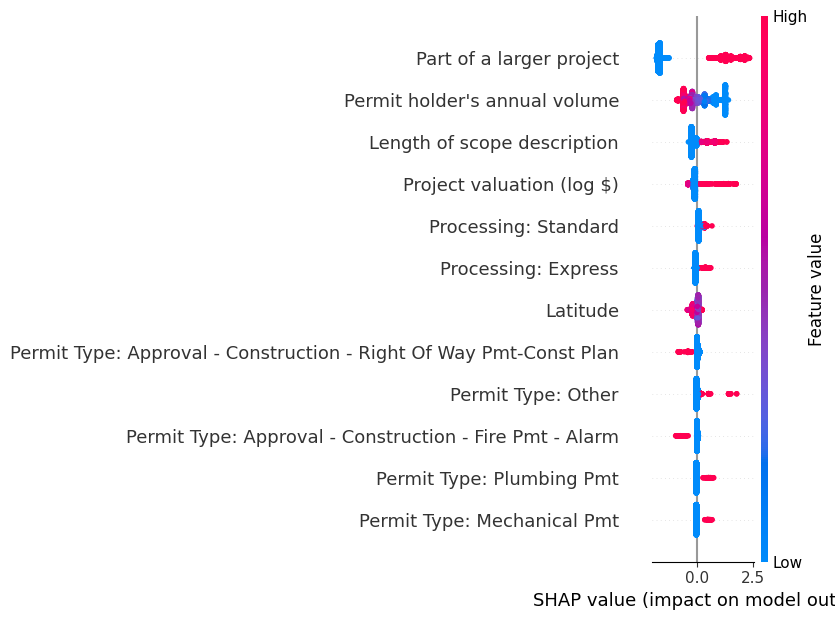

In [5]:
import shap

model_raw = joblib.load("model_v2.pkl")
feature_cols = joblib.load("features_v2.pkl")
top_types = list(joblib.load("top_15_types.pkl"))
holder_freq = joblib.load("holder_freq.pkl")

X_test = engineer_features(test_df, top_types, holder_freq)[feature_cols]
sample = X_test.sample(3000, random_state=42)

explainer = shap.TreeExplainer(model_raw)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample,
                  feature_names=[friendly_name(c) for c in feature_cols],
                  max_display=12)

The v1 story ("permit type dominates") survives but gets more textured: project linkage and the processing track now sit alongside the big permit-type indicators, and holder volume contributes a steady contractor-experience effect. Month remains marginal — its v1 importance was partly proxying for things v2 now measures directly.

## 4. Where the model is still wrong

Aggregate metrics hide failure modes, so [`error_analysis.py`](error_analysis.py) breaks 2025 down properly ([full report](reports/error_analysis.md)). The short version:

In [6]:
pred = (model_raw.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
t = test_df.assign(y=y_test, pred=pred)
t["type_grouped"] = t["APPROVAL_TYPE"].where(
    t["APPROVAL_TYPE"].isin(top_types), "Other")

rows = []
for name, g in t.groupby("type_grouped"):
    tp = ((g.y == 1) & (g.pred == 1)).sum()
    fn = ((g.y == 1) & (g.pred == 0)).sum()
    fp = ((g.y == 0) & (g.pred == 1)).sum()
    rows.append({"type": name, "n": len(g), "delay_rate": g.y.mean(),
                 "recall": tp / (tp + fn) if tp + fn else np.nan,
                 "precision": tp / (tp + fp) if tp + fp else np.nan})
(pd.DataFrame(rows).sort_values("n", ascending=False)
   .set_index("type").round(3))

,n,delay_rate,recall,precision
type,,,,
Traffic Control Permit,9681,0.007,0.000,NaN
No-Plan - Residential - Combination Mech/Elec/Plum,9649,0.006,0.000,NaN
Photovoltaic - SB 379,5986,0.008,0.000,0.000
Other,4690,0.495,0.768,0.632
Combination Building Permit,4570,0.625,0.960,0.679
Building Permit,2848,0.632,0.911,0.685
Approval - Construction - Right Of Way Pmt-Const Plan,2748,0.382,0.115,0.756
Electrical Pmt,2305,0.733,0.946,0.748
No-Plan - Nonresidential/Multifamily - Electrical,1916,0.014,0.000,NaN


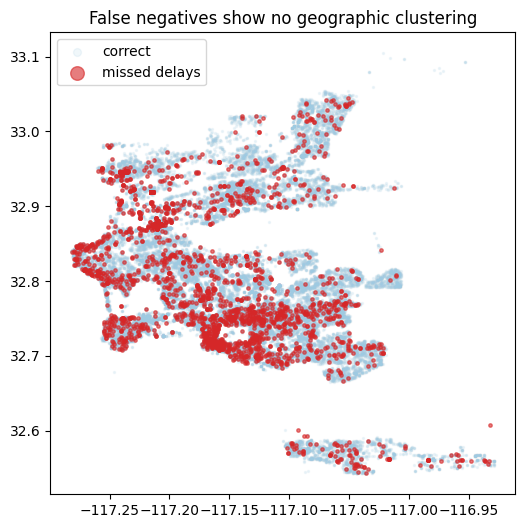

missed delays: 2,358 (19.4% of delayed permits)
median actual delay among misses: 148 days (vs 192 for all delayed)


In [7]:
fn = t[(t.y == 1) & (t.pred == 0)]
ok = t[t.y == t.pred]
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ok.GIS_LONGITUDE, ok.GIS_LATITUDE, s=2, alpha=0.15,
           c="#9ecae1", label="correct")
ax.scatter(fn.GIS_LONGITUDE, fn.GIS_LATITUDE, s=6, alpha=0.6,
           c="#d62728", label="missed delays")
ax.set_title("False negatives show no geographic clustering")
ax.legend(markerscale=4)
plt.show()

print(f"missed delays: {len(fn):,} ({len(fn)/(t.y==1).sum():.1%} of delayed permits)")
print(f"median actual delay among misses: {fn.days_to_approval.median():.0f} days "
      f"(vs {t[t.y==1].days_to_approval.median():.0f} for all delayed)")

The model is near-perfect on routine types and catches 91-96% of delays on the classic plan-review types. The two genuine blind spots are **Right-of-Way construction permits** (38% delay rate, 11.5% recall) and **Fire Alarm permits** (22%, 11%) — whatever delays those isn't captured by project linkage, valuation, or any current feature. That's the clearest pointer for a v3: find the variable that separates slow Right-of-Way permits from fast ones.

## Wrap-up

- **v2 model**: 87.3% accuracy / 0.942 AUC / 80.6% recall on a held-out future year (v1: 85.1% / 0.916 / 74.9%)
- **The lift came from feature mining**, not model tuning — the biggest signals were hiding in sparsely-populated columns
- **Known blind spots documented** rather than averaged away

Next candidates: drift monitoring on incoming 2026 data, and digging into the Right-of-Way blind spot. (An earlier iteration also explored probability calibration and user-chosen deadline thresholds — that work was descoped to keep the project focused, with the full reasoning preserved in [DECISIONS.md](DECISIONS.md).)